# Rabi oscillation

In [1]:
from pathlib import Path

import numpy as np

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal09_rabi import Rabi

## Run parameters

In [2]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "rabi"

QUBITS = ["q1"]

# Two arrays give a 2D Rabi sweep. Replace either one with a scalar for a 1D sweep.
DRIVE_AMPLITUDES = np.arange(start=0.0, stop=0.9, step=0.01)    # 2D sweep
# DRIVE_AMPLITUDES = 0.1  # time Rabi
# DRIVE_DURATIONS = np.arange(start=4, stop=200, step=4, dtype=float) * 1e-9    # 2D sweep
DRIVE_DURATIONS = 30e-9  # power Rabi
REPETITIONS = 200
RESET_TYPE = "thermal"  # "thermal" or "active" (ConditionalReset)

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
TIMEOUT = 100
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config  # Use None to skip persistence

## Hardware and experiment

In [3]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = Rabi(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [4]:
dataset = experiment.run_measurement(
    drive_amplitudes=DRIVE_AMPLITUDES,
    drive_durations=DRIVE_DURATIONS,
    repetitions=REPETITIONS,
    reset_type=RESET_TYPE,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 4kB
Dimensions:             (acq_index_S21_q1: 90)
Coordinates:
    drive_duration_q1   (acq_index_S21_q1) float64 720B 3e-08 3e-08 ... 3e-08
    drive_amplitude_q1  (acq_index_S21_q1) float64 720B 0.0 0.01 ... 0.88 0.89
  * acq_index_S21_q1    (acq_index_S21_q1) int64 720B 0 1 2 3 4 ... 86 87 88 89
Data variables:
    S21_q1              (acq_index_S21_q1) complex128 1kB (-0.002020687658786...
Attributes:
    tuid:     20260915-142456-531-8825da

## Optional: Simulated data

In [5]:
# dataset = experiment.simulated_data(
#     drive_amplitudes=DRIVE_AMPLITUDES,
#     drive_durations=DRIVE_DURATIONS,
#     repetitions=REPETITIONS,
#     pi_pulse_amplitude=0.1,
#     pi_pulse_duration=50e-9,
#     noise=0.002,
#     seed=42,
# )

## Plot raw data

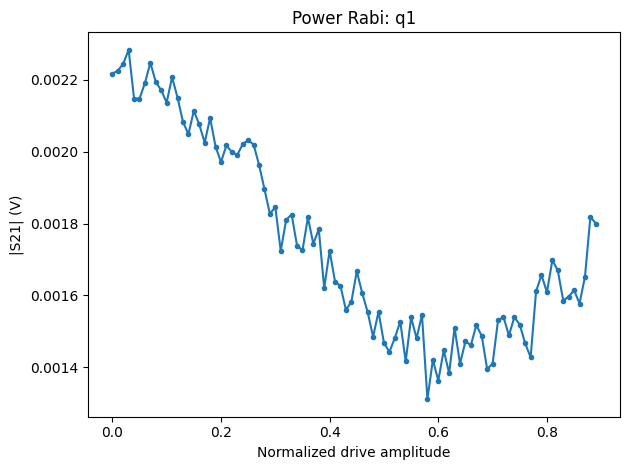

In [6]:
experiment.plot_data()

## Analysis

In [7]:
ANALYSIS_MODE = "power"  # "power" or "time"
ANALYSIS_DRIVE_DURATION = 30e-9  # Required in power mode
ANALYSIS_DRIVE_AMPLITUDE = 0.1  # Required in time mode
CALIBRATION_POINTS = True  # Rotate the complex data onto its highest-SNR axis

In [8]:
analysis_arguments = {
    "mode": ANALYSIS_MODE,
    "calibration_points": CALIBRATION_POINTS,
}
if ANALYSIS_MODE == "power":
    analysis_arguments["drive_duration"] = ANALYSIS_DRIVE_DURATION
elif ANALYSIS_MODE == "time":
    analysis_arguments["drive_amplitude"] = ANALYSIS_DRIVE_AMPLITUDE

results = experiment.analysis(**analysis_arguments)
for qubit, result in results.items():
    if not result.success:
        print(f"{qubit}: Rabi fit failed")
    elif result.mode == "power":
        print(
            f"{qubit}: pi-pulse amplitude = {result.pi_pulse_amplitude:.9g} "
            f"at {result.selected_drive_duration / 1e-9:.3f} ns"
        )
    else:
        print(
            f"{qubit}: pi-pulse duration = {result.pi_pulse_duration / 1e-9:.3f} ns "
            f"at amplitude {result.selected_drive_amplitude:.9g}"
        )

q1: pi-pulse amplitude = 0.624588135 at 30.000 ns


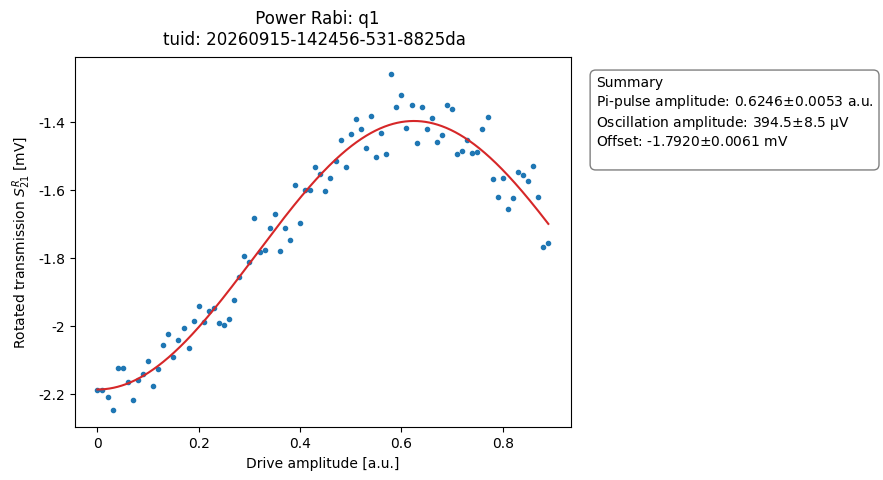

In [9]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [10]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


In [11]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [11]:
from qcodes.instrument import Instrument

Instrument.close_all()